## Imports

In [ ]:
!pip install ipywidgets --quiet

import os
import keras
import zipfile
import numpy as np
from keras import ops
import ipywidgets as widgets
from google.colab import drive
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import img_to_array, load_img

## Accessing the Dataset uploaded on Google Drive

In [ ]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/Dataset.zip'
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

## Loading and Preprocessing the Dataset

In [3]:
def load_images(folder_path, target_size=(128, 128), rotate_class='0', rotate_angle=-90):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder_path))
    label_mapping = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder_path, class_name)
        label_value = label_mapping[class_name]
        count = 0

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = load_img(img_path, target_size=target_size)

            if class_name == rotate_class:
                img = img.rotate(rotate_angle)

            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(label_value)
            count += 1

        print(f'Class "{class_name}": {count} images loaded')

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

## Splitting the Dataset

In [4]:
dataset_path = '/content/Dataset'
images, labels = load_images(dataset_path)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=42)

print(f'\nTraining samples: {len(X_train)}')
print(f'Test  samples: {len(X_test)}')

Class "0": 103 images loaded
Class "1": 101 images loaded

Training samples: 163
Test  samples: 41


## Visualizing some samples

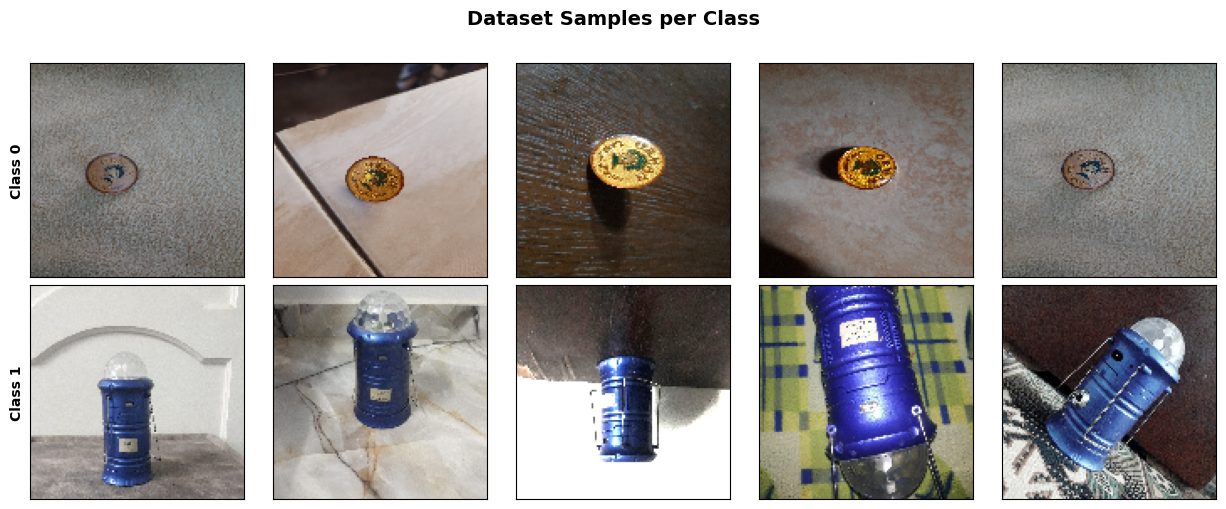

In [5]:
def show_dataset_samples(images, labels, num_classes=2, samples_per_class=5):
    """Display a grid of sample images from each class."""
    fig, axes = plt.subplots( num_classes, samples_per_class, figsize=(samples_per_class * 2.5, num_classes * 2.5))
    fig.suptitle('Dataset Samples per Class', fontsize=14, fontweight='bold', y=1.01)

    for cls in range(num_classes):
        class_images = images[labels == cls]
        for j in range(samples_per_class):
            ax = axes[cls, j] if num_classes > 1 else axes[j]
            if j < len(class_images):
                ax.imshow(class_images[j])
            else:
                ax.axis('off')
            ax.set_xticks([])
            ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(f'Class {cls}', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_dataset_samples(images, labels)

## Constructing the CVAE model architecture

In [ ]:
# Parameters
IMG_SIZE     = (128, 128)
original_dim = 128 * 128 * 3
latent_dim   = 128
num_classes  = 2

#Sampling Layer
class SamplingLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator()

    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=ops.shape(z_mean), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

    def compute_output_shape(self, input_shape):
        return input_shape[0]

# Encoder
image_input    = layers.Input(shape=(original_dim,))
label_input    = layers.Input(shape=(num_classes,))

# Compress image first before concatenating label
x             = layers.Dense(512, activation='relu')(image_input)
x             = layers.BatchNormalization()(x)
merged_encoder = layers.Concatenate()([x, label_input])             

x         = layers.Dense(256, activation='relu')(merged_encoder)
x         = layers.BatchNormalization()(x)
x         = layers.Dense(128, activation='relu')(x)

z_mean    = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z_log_var = layers.Lambda(lambda t: ops.clip(t, -4, 4))(z_log_var)
z         = SamplingLayer()([z_mean, z_log_var])

encoder = keras.Model([image_input, label_input], [z_mean, z_log_var, z], name='encoder')

# Decoder
latent_input        = layers.Input(shape=(latent_dim,))
decoder_label_input = layers.Input(shape=(num_classes,))
merged_decoder      = layers.Concatenate()([latent_input, decoder_label_input])

x          = layers.Dense(128, activation='relu')(merged_decoder)
x          = layers.BatchNormalization()(x)
x          = layers.Dense(256, activation='relu')(x)
x          = layers.BatchNormalization()(x)
x          = layers.Dense(512, activation='relu')(x)
output_img = layers.Dense(original_dim, activation='sigmoid')(x)

decoder = keras.Model([latent_input, decoder_label_input], output_img, name='decoder')

# CVAE
image_input2 = layers.Input(shape=(original_dim,))
label_input2 = layers.Input(shape=(num_classes,))

z_mean_out, z_log_var_out, z_out = encoder([image_input2, label_input2])
cvae_outputs = decoder([z_out, label_input2])

full_output = layers.Concatenate()([cvae_outputs, z_mean_out, z_log_var_out])
cvae = keras.Model([image_input2, label_input2], full_output, name='cvae')

# Loss
def total_loss(y_true, y_pred):
    recon       = y_pred[:, :original_dim]
    z_mean_l    = y_pred[:, original_dim : original_dim + latent_dim]
    z_log_var_l = y_pred[:, original_dim + latent_dim:]

    reconstruction_loss = ops.mean(ops.sum(ops.square(y_true - recon), axis=1))
    kl_loss             = -0.5 * ops.mean(ops.sum(1 + z_log_var_l - ops.square(z_mean_l) - ops.exp(z_log_var_l), axis=1))
    return reconstruction_loss + kl_loss

## Compiling and Training the CVAE model

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
cvae.compile(optimizer=optimizer, loss=total_loss)

X_train_flat = X_train.reshape(-1, original_dim)
y_train_cat  = keras.utils.to_categorical(y_train, num_classes)

cvae.fit(
    [X_train_flat, y_train_cat],
    X_train_flat,
    epochs     = 300,
    batch_size = 32,
    callbacks  = [
        keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
        keras.callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True, verbose=1),
    ]
)

Epoch 1/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 236ms/step - loss: 2580.2458 - learning_rate: 1.0000e-04
Epoch 2/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1919.0360 - learning_rate: 1.0000e-04
Epoch 3/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1666.9545 - learning_rate: 1.0000e-04
Epoch 4/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1493.3268 - learning_rate: 1.0000e-04
Epoch 5/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1319.1139 - learning_rate: 1.0000e-04
Epoch 6/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1221.8783 - learning_rate: 1.0000e-04
Epoch 7/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1159.8447 - learning_rate: 1.0000e-04
Epoch 8/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1130.1891 - learning_rate: 1.0000e-04
Epoch 9/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1078.3843 - learning_rate: 1.0000e-04
Epoch 10/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1016.8461 - learning_rate: 1.0000e-04
Epoch 11/300
31/3

## Implementing a GUI to control the number of generated images conditioned on class 1

IntSlider(value=3, description='Count:', max=10, min=1)

Dropdown(description='Label:', index=1, options=(('Class 0', 0), ('Class 1', 1)), value=1)

Button(description='Generate Images', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


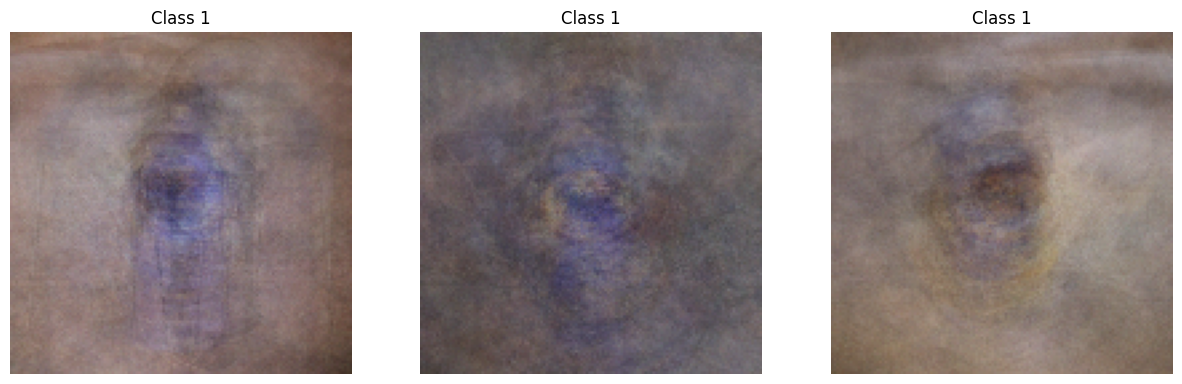

In [9]:
def generate_images(num_to_gen, class_id):
    # Create the labels (one-hot)
    target_label = np.zeros((num_to_gen, num_classes))
    target_label[:, class_id] = 1

    # Sample random points from the latent space
    random_latent_vectors = np.random.normal(size=(num_to_gen, latent_dim))

    # Decode them
    decoded_imgs = decoder.predict([random_latent_vectors, target_label])
    decoded_imgs = decoded_imgs.reshape(num_to_gen, 128, 128, 3)

    # Plot
    plt.figure(figsize=(15, 5))
    for i in range(num_to_gen):
        ax = plt.subplot(1, num_to_gen, i + 1)
        plt.imshow(decoded_imgs[i])
        plt.title(f"Class {class_id}")
        plt.axis("off")
    plt.show()

# GUI Widgets
num_slider = widgets.IntSlider(value=3, min=1, max=10, step=1, description='Count:')
class_dropdown = widgets.Dropdown(options=[('Class 0', 0), ('Class 1', 1)], description='Label:')
button = widgets.Button(description="Generate Images")

def on_button_clicked(b):
    clear_output(wait=True)
    display(num_slider, class_dropdown, button)
    generate_images(num_slider.value, class_dropdown.value)

button.on_click(on_button_clicked)
display(num_slider, class_dropdown, button)

## Implementing a GUI to control the number of generated images conditioned on class 0

IntSlider(value=3, description='Count:', max=10, min=1)

Dropdown(description='Label:', options=(('Class 0', 0), ('Class 1', 1)), value=0)

Button(description='Generate Images', style=ButtonStyle())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


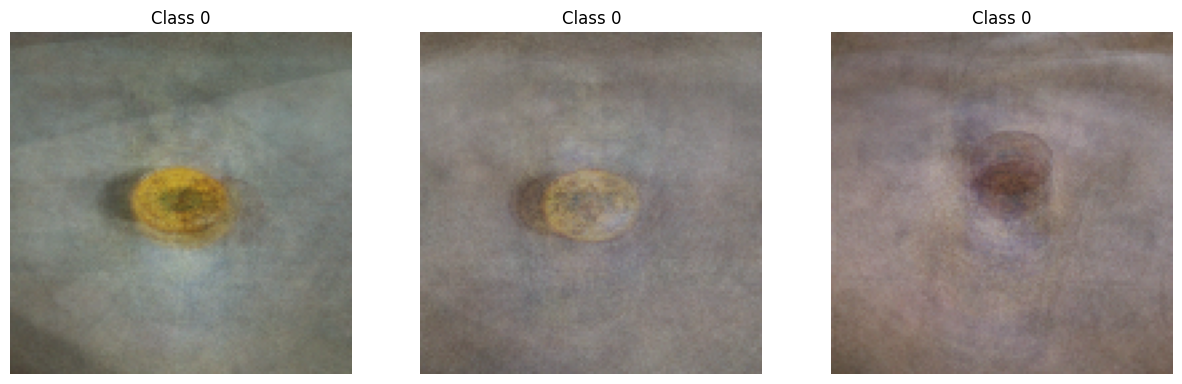

In [10]:
def generate_images(num_to_gen, class_id):
    # Create the labels (one-hot)
    target_label = np.zeros((num_to_gen, num_classes))
    target_label[:, class_id] = 1

    # Sample random points from the latent space
    random_latent_vectors = np.random.normal(size=(num_to_gen, latent_dim))

    # Decode them
    decoded_imgs = decoder.predict([random_latent_vectors, target_label])
    decoded_imgs = decoded_imgs.reshape(num_to_gen, 128, 128, 3)

    # Plot
    plt.figure(figsize=(15, 5))
    for i in range(num_to_gen):
        ax = plt.subplot(1, num_to_gen, i + 1)
        plt.imshow(decoded_imgs[i])
        plt.title(f"Class {class_id}")
        plt.axis("off")
    plt.show()

# GUI Widgets
num_slider = widgets.IntSlider(value=3, min=1, max=10, step=1, description='Count:')
class_dropdown = widgets.Dropdown(options=[('Class 0', 0), ('Class 1', 1)], description='Label:')
button = widgets.Button(description="Generate Images")

def on_button_clicked(b):
    clear_output(wait=True)
    display(num_slider, class_dropdown, button)
    generate_images(num_slider.value, class_dropdown.value)

button.on_click(on_button_clicked)
display(num_slider, class_dropdown, button)